In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:

block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [7]:
# Variable initialization
emb_dimension = 10
neurons_in_layer_1 = 200
learning_rate = 0.1

In [8]:
# mlp architecture
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, emb_dimension), generator=g, device=device)
w1 = torch.randn((block_size*emb_dimension, neurons_in_layer_1), generator=g, device=device) * (5/3)/ ((block_size*emb_dimension)**0.5)
b1 = torch.randn(neurons_in_layer_1, generator=g, device=device)                    * 0.01
# w2 = torch.randn((neurons_in_layer_1, neurons_in_layer_2), generator=g)
# b2 = torch.randn(neurons_in_layer_2, generator=g)
w2 = torch.randn((neurons_in_layer_1, vocab_size), generator=g, device=device)      * 0.01
b2 = torch.randn(vocab_size, generator=g, device=device)                            * 0

bngain = torch.ones((1, neurons_in_layer_1), device=device)
bnbias = torch.zeros((1, neurons_in_layer_1), device=device)
bnmean_running = torch.zeros((1, neurons_in_layer_1), device=device)
bnstd_running = torch.ones((1, neurons_in_layer_1), device=device)

parameters = [C, w1, b1, w2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True
    p.data = p.data.to(device)

In [17]:
batch_size = 32
epochs = 20000
lossi = []

for epoch in range(epochs): 

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    bnmeani = h1.mean(0, keepdim=True)
    bnstdi = h1.std(0, keepdim=True)
    h1 = bngain * (h1 - bnmeani) / (bnstdi + 1e-5) + bnbias  # LayerNorm
    h1 = torch.tanh(h1)
    logits = h1 @ w2 + b2
    loss = F.cross_entropy(logits, Yb)
    lossi.append(loss.item())

    with torch.no_grad():
        bnmean_running = 0.9 * bnmean_running + 0.1 * bnmeani
        bnstd_running = 0.9 * bnstd_running + 0.1 * bnstdi

    # backward pass
    for p in parameters:
        p.grad = None  
    loss.backward()

    lr = 0.1 if epoch < 10000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 2.1876
Epoch 1000, Loss: 2.3330
Epoch 2000, Loss: 2.1701
Epoch 3000, Loss: 2.1594
Epoch 4000, Loss: 1.7676
Epoch 5000, Loss: 2.3129
Epoch 6000, Loss: 2.0246
Epoch 7000, Loss: 2.0400
Epoch 8000, Loss: 2.2152
Epoch 9000, Loss: 1.9096
Epoch 10000, Loss: 2.0898
Epoch 11000, Loss: 2.0532
Epoch 12000, Loss: 2.0362
Epoch 13000, Loss: 2.2625
Epoch 14000, Loss: 2.1044
Epoch 15000, Loss: 2.0964
Epoch 16000, Loss: 2.1393
Epoch 17000, Loss: 2.3983
Epoch 18000, Loss: 2.3487
Epoch 19000, Loss: 1.9764


(array([352., 210., 198., 181., 156., 133., 134., 143., 111., 122., 100.,
         84., 107., 101.,  84., 124., 108., 102.,  82., 121., 100.,  93.,
        107., 101., 109., 125.,  98., 108.,  99.,  91.,  92., 103., 100.,
         97., 101.,  92.,  89., 105.,  90., 108.,  93.,  93., 114., 122.,
        144., 152., 144., 191., 206., 380.]),
 array([-9.99982893e-01, -9.59983276e-01, -9.19983659e-01, -8.79984041e-01,
        -8.39984424e-01, -7.99984807e-01, -7.59985189e-01, -7.19985572e-01,
        -6.79985955e-01, -6.39986337e-01, -5.99986720e-01, -5.59987103e-01,
        -5.19987485e-01, -4.79987868e-01, -4.39988251e-01, -3.99988633e-01,
        -3.59989016e-01, -3.19989399e-01, -2.79989781e-01, -2.39990164e-01,
        -1.99990547e-01, -1.59990929e-01, -1.19991312e-01, -7.99916947e-02,
        -3.99920774e-02,  7.53998756e-06,  4.00071573e-02,  8.00067747e-02,
         1.20006392e-01,  1.60006009e-01,  2.00005627e-01,  2.40005244e-01,
         2.80004861e-01,  3.20004479e-01,  3.60004

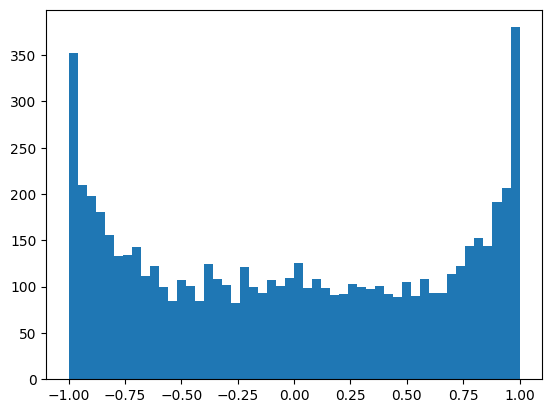

In [18]:
plt.hist(h1.view(-1).tolist(), 50)

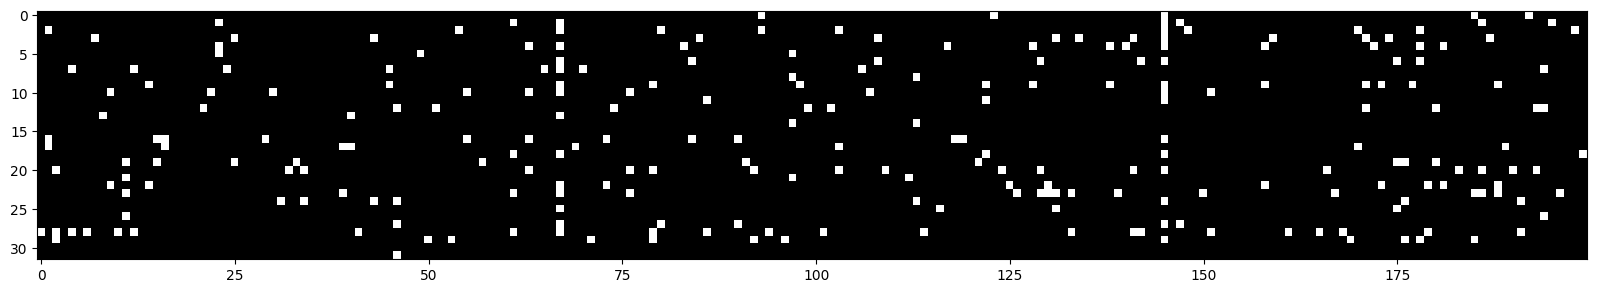

In [19]:
plt.figure(figsize=(20,50))
plt.imshow(h1.abs().cpu().detach() > 0.99, cmap='gray', interpolation='nearest')

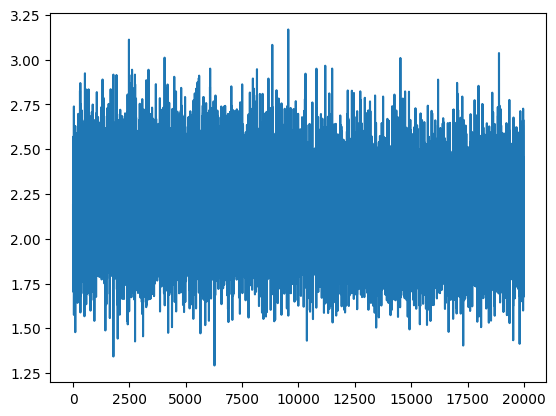

In [20]:
plt.plot(lossi)

In [ ]:
with torch.no_grad():
    emb = C[Xtes]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    bnmean = h1.mean(0, keepdim=True)
    bnstd = h1.std(0, keepdim=True)

In [21]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtes, Ytes)
    }[split]
    emb = C[x]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    # h1 = bngain * (h1 - h1.mean(0, keepdim=True)) / (h1.std(0, keepdim=True) + 1e-5) + bnbias  # LayerNorm
    h1 = bngain * (h1 - bnmean_running) / (bnstd_running + 1e-5) + bnbias  # LayerNorm
    h1 = torch.tanh(h1)
    logits = h1 @ w2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.0915
val loss: 2.1245


In [22]:
g = torch.Generator(device=device).manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context], device=device)]
        formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
        h1 = formatted_input @ w1 + b1 
        h1 = torch.tanh(h1)
        logits = h1 @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

khedkeszinglmwillagombiahsmmrqssin.
mckxot.
kafshirlizmarlilliershilic.
ndilynnleizos.
draylistekishahswoellstin.
j.
shndsj.
jolynnainxxxn.
shondaltailaliffd.
magrelis.
mdrleelscayciesna.
mkoclawsuvingch.
nslynnquxwilgfelnarkizabellahswi.
sha.
joytha.
viketza.
jidnyaldaenslkil.
dckslakalzmegundtrrwemmalib.
shzurnvlynnnicharleigh.
kha.
